100002453

'Consumer Cyclical'


Let's start importing the uncleaned dataset

In [ ]:
import pandas as pd
import numpy as np


df_raw= pd.read_csv('/Users/chris/Desktop/ChristianBDA2026/data/symbol_info_3-25.csv')
print("Dataset shape:", df_raw.shape)
df_raw.head()
# Now just clean our dataset, removing ETFs and Funds


summary = pd.DataFrame({

    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100)
})
summary




Dataset shape: (1000, 38)


,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


let's remove all the unmissed data

In [6]:
summary = pd.DataFrame({

    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean().values * 100)
})
summary

,column,dtype,missing_values,missing_pct
0,symbol,str,0,0.0
1,company_name,str,0,0.0
2,sector,str,2,0.2
3,industry,str,2,0.2
4,market_cap,int64,0,0.0
5,enterprise_value,uint64,0,0.0
6,current_price,float64,0,0.0
7,previous_close,float64,0,0.0
8,fifty_two_week_high,float64,0,0.0
9,fifty_two_week_low,float64,0,0.0


Clean teh dataset

In [7]:
df = df_raw.copy()

df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

df["market_cap_b"]       = df["market_cap"]      / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"]          = df["total_revenue"]    / 1e9
df["net_income_b"]       = df["net_income"]       / 1e9
df["free_cashflow_b"]    = df["free_cashflow"]    / 1e9

df["profit_margin_pct"]  = df["profit_margins"]   * 100
df["revenue_growth_pct"] = df["revenue_growth"]   * 100
df["earnings_growth_pct"]= df["earnings_growth"]  * 100
df["return_on_assets_pct"]= df["return_on_assets"]* 100
df["return_on_equity_pct"]= df["return_on_equity"]* 100

df["dividend_yield_pct"] = df["dividend_yield"]
df = df.replace([np.inf, -np.inf], np.nan)

print("Cleaned investment universe:", df.shape)

Cleaned investment universe: (993, 49)


peak the consumer cycling sectors

In [10]:

df_Consumer_C = df[df['sector'] == 'Consumer Cyclical']
print(df_Consumer_C)



    symbol                 company_name             sector  \
3     AMZN             Amazon.com, Inc.  Consumer Cyclical   
11    TSLA                  Tesla, Inc.  Consumer Cyclical   
25      HD       Home Depot, Inc. (The)  Consumer Cyclical   
39     MCD       McDonald's Corporation  Consumer Cyclical   
50     PDD            PDD Holdings Inc.  Consumer Cyclical   
..     ...                          ...                ...   
985     AN             AutoNation, Inc.  Consumer Cyclical   
991   BBWI      Bath & Body Works, Inc.  Consumer Cyclical   
993    EAT  Brinker International, Inc.  Consumer Cyclical   
997    VFC             V.F. Corporation  Consumer Cyclical   
999    BWA              BorgWarner Inc.  Consumer Cyclical   

                     industry     market_cap  enterprise_value  current_price  \
3             Internet Retail  2079374704640     2133579530240     196.210007   
11         Auto Manufacturers   799980716032      777646112768     248.710007   
25    Home I

Grapich


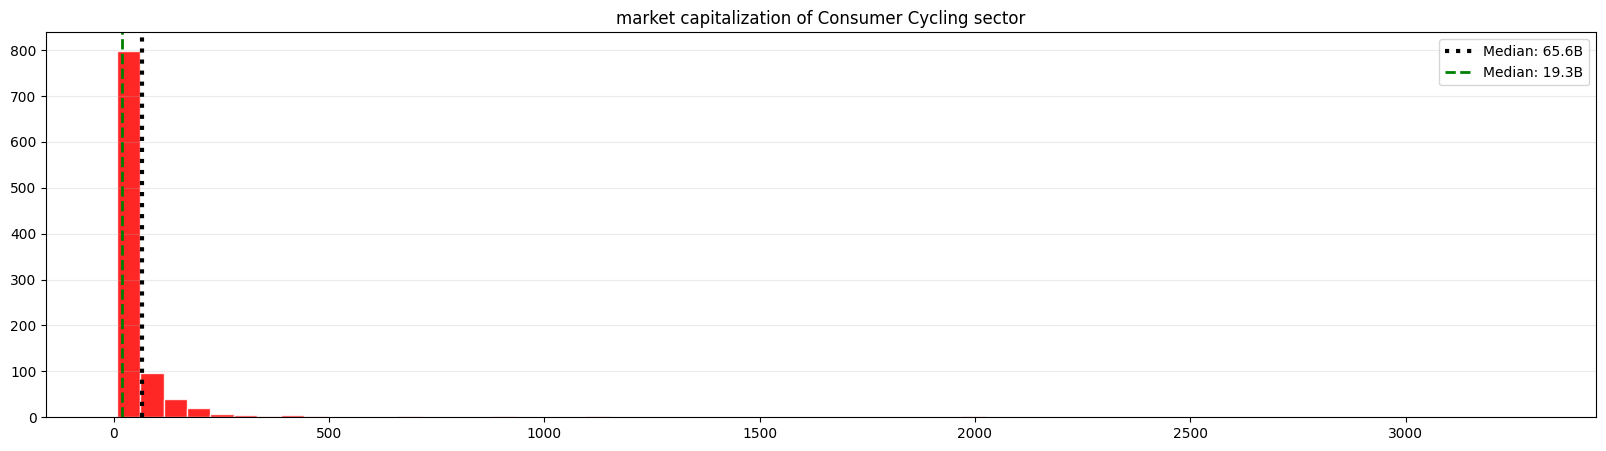

In [36]:
import matplotlib.pyplot as plt

market_cap_C = df['market_cap_b'].dropna()

fig, ax = plt.subplots(figsize=(20, 5))

ax.hist(
    market_cap_C,
    bins = 60,
    color = 'red',
    edgecolor = 'white',
    alpha = 0.85
)

Mean_value = market_cap_C.mean()
Median_value = market_cap_C.median()

ax.axvline(Mean_value, color = 'black', linestyle = ':', linewidth = 3, label=f"Median: {Mean_value:,.1f}B")
ax.axvline(Median_value, color = 'green', linestyle = '--', linewidth = 2, label= f"Median: {Median_value:,.1f}B")

ax.set_title("market capitalization of Consumer Cycling sector")
ax.grid(axis="y", alpha=0.25)

ax.legend()
plt.show()